In [1]:
from typing import Dict, TypedDict, List
from langgraph.graph import StateGraph, START, END

c:\Users\ka448\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [2]:
class AgentState(TypedDict):
    name: str
    count: int

In [3]:
def name_node(state: AgentState) -> AgentState:
    state['name'] = f"Hi {state['name']}"
    state['count'] = 0
    print(state['name'])
    return state

In [4]:
def decider(state: AgentState) -> AgentState:
    if state['count'] < 5:
        print(f"Count is {state['count']}")
        return "loop"
    else:
        return "exit"
    


def addCount(state: AgentState) -> AgentState:
    state['count'] += 1
    return state

In [5]:
graph = StateGraph(AgentState)

In [6]:
graph.add_node("Name", name_node)
graph.add_node("Count", addCount)
graph.set_entry_point("Name")
graph.add_edge("Name", "Count")


graph.add_conditional_edges("Count", decider, {"loop": "Count", "exit": END})

graph.set_finish_point("Count")

In [7]:
test = graph.compile()

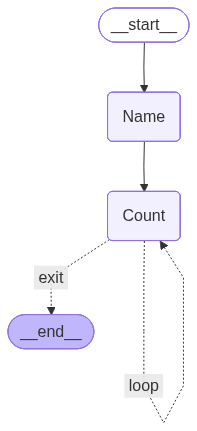

In [8]:
test

In [9]:
result = test.invoke({"name": "Alice"})

Hi Alice
Count is 1
Count is 2
Count is 3
Count is 4
